## First step we will do a EDA to undestand the data and the core goal problem

#### the main goal of this challenge is: use machine learning or deep learning to create a model that predicts which passengers survived the Titanic shipwreck. Also, we want analyze the data and undestanting if titanic survivors has relansiship with power economic like if you are rich you have more chance to surviver them other

In [51]:
# We will import two libs now one is panda to update file and another is matplotlib to visualization somethings about data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as srn
import statistics as sts
 

In [52]:
# for now we will explory the train data without see the test
data_train = pd.read_csv('train.csv')

#### kaggle documentation about the data is here https://www.kaggle.com/competitions/titanic/data

#### What each column is: pclass: A proxy for socio-economic status (SES)
#### 1st = Upper
#### 2nd = Middle
#### 3rd = Lower
#### age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5
#### sibsp: The dataset defines family relations in this way...
#### Sibling = brother, sister, stepbrother, stepsister
#### Spouse = husband, wife (mistresses and fiancés were ignored)
#### parch: The dataset defines family relations in this way...
#### Parent = mother, father
#### Child = daughter, son, stepdaughter, stepson
#### Some children travelled only with a nanny, therefore parch=0 for them.

#### Survival	0 = No, 1 = Yes
#### pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
#### sex	Sex	
#### Age	Age in years	
#### sibsp	# of siblings / spouses aboard the Titanic	
#### parch	# of parents / children aboard the Titanic	
#### ticket	Ticket number	
#### fare	Passenger fare	
#### cabin	Cabin number	
#### embarked	Port of Embarkation

In [53]:
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
data_train.shape

(891, 12)

In [55]:
# lets view a overview about data:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Interesting, we have some missing values, especially in the age column (which might be an important feature for our prediction). Also, have missing values in Cabin,  However, we also have missing values in Embarked, the port where the customer boarded. In this case, there are only 2 missing values in Embarked. We need know how we will handle with this missing values we can use mode or median to fill this missing values maybe?. End of this EDA we will decide this.

In [7]:
# Lets check if we have null values
print(data_train.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### We will handle with miss values using mode and mean

In [8]:
# Lets get a mode and median about this columns with missing values

# which is mode:
cabin_mode = data_train["Cabin"].mode()[0] 
print("Cabin mode", cabin_mode)

# Age median, and median:
age_median = data_train["Age"].median()
print("Age median", age_median)

age_mean = data_train["Age"].mean()
print("Age mean", age_mean)

# Enbarked mode:
enbarked_mode = data_train["Embarked"].mode()[0] 
print("Enbarked mode", enbarked_mode)



Cabin mode B96 B98
Age median 28.0
Age mean 29.69911764705882
Enbarked mode S


In [9]:
# Lets fill null values
# Data with media 
data_train["Age"] = data_train["Age"].fillna(28)
# Here we put a mode in all case
data_train["Cabin"] = data_train["Cabin"].fillna("B96 B98")
data_train["Embarked"] = data_train["Embarked"].fillna("S")


In [10]:
print(data_train.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


#### lets keep explore data 

I want answers some questions like The age influence in survive? The p_class too? And Enbarked gate? Ticket?  Lets use correlation to see if have some correlation with values

In [11]:
data_train_analytics = data_train.drop(columns=["PassengerId", "Name"])


##### If we look the correlation values between survived and other atributes we don't have much relanshaip 
##### just with Fare a little by and sibps with parch which make sense between this two Sibling = brother, sister, stepbrother, stepsister
##### Spouse = husband, wife

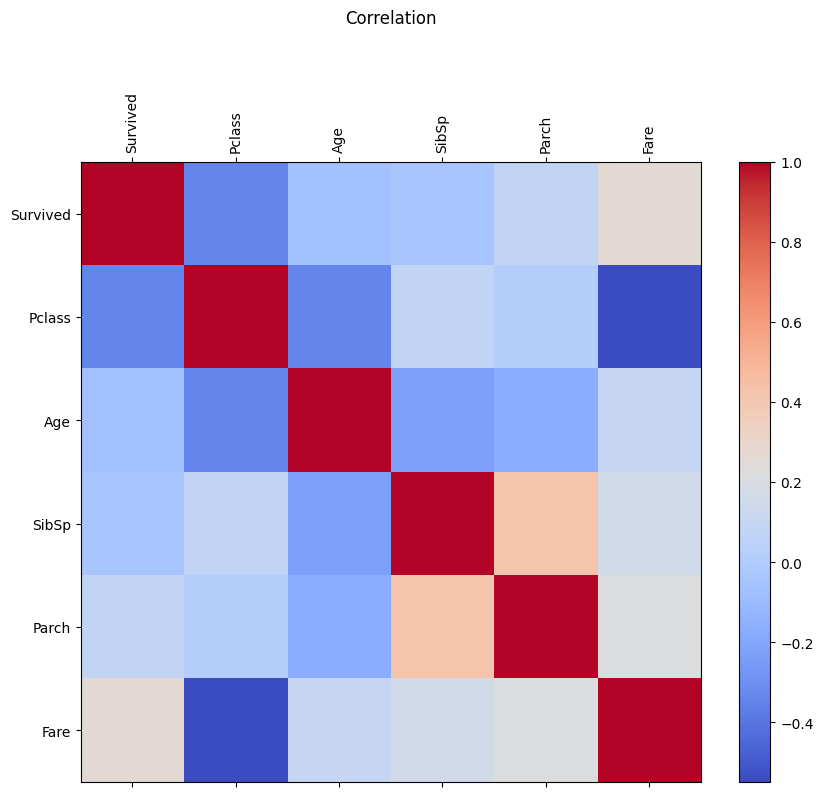

In [12]:
correlation = data_train_analytics.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.matshow(correlation, cmap='coolwarm', fignum=1)
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.colorbar()
plt.title("Correlation", pad=100)
plt.show()

### We will explore categorical and numerical variables

##### We can observe a certain degree of class imbalance between those who survived and those who did not, with more non-survivors than survivors.

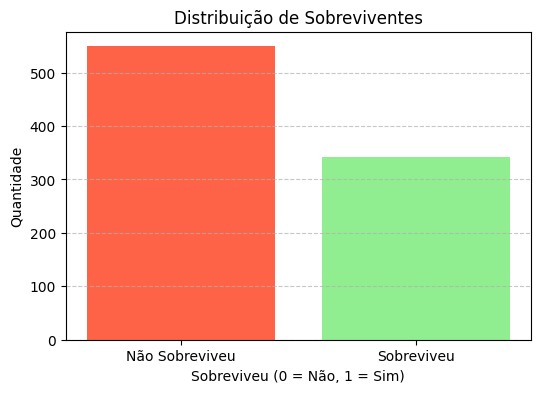

In [56]:
count = data_train_analytics['Survived'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(contagem.index.astype(str), count.values, color=['tomato', 'lightgreen'])

plt.title('Distribuição de Sobreviventes')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Não Sobreviveu', 'Sobreviveu'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### We can observe that class 3 has the highest number of non-survivors, while class 1 has the highest number of survivors.

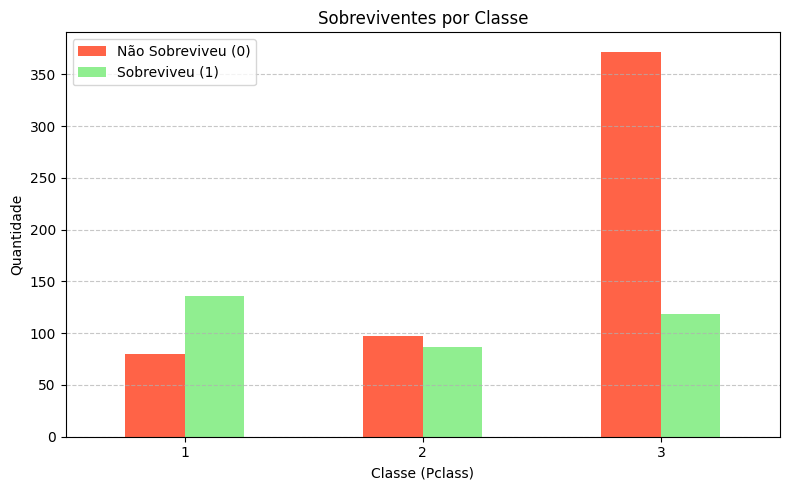

In [14]:
# Crosstab between Survived e Pclass
tabela = data_train_analytics.groupby(['Pclass', 'Survived']).size().unstack()

tabela.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])

plt.title('Sobreviventes por Classe')
plt.xlabel('Classe (Pclass)')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### We grouped the ages into value ranges to understand which age group had the highest number of survivors. We can observe that the 21 to 40 age group has the largest number of people, as well as the highest number of both survivors and non-survivors.

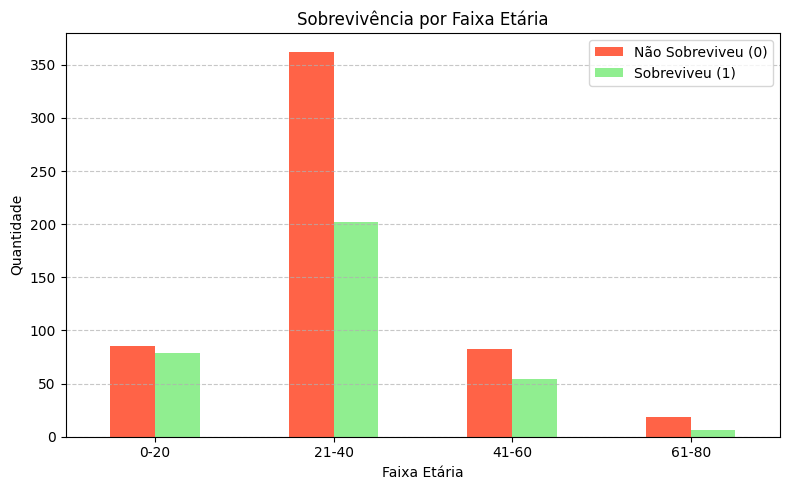

In [57]:
bins = [0, 20, 40, 60, 80]
labels = ['0-20', '21-40', '41-60', '61-80']

ranges = pd.cut(data_train_analytics['Age'], bins=bins, labels=labels, right=False)

tabela = pd.crosstab(ranges, data_train_analytics['Survived'])

tabela.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])

plt.title('Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interestingly, when we look at gender, the majority are male; however, when we focus on females, they represent the majority of the survivors.

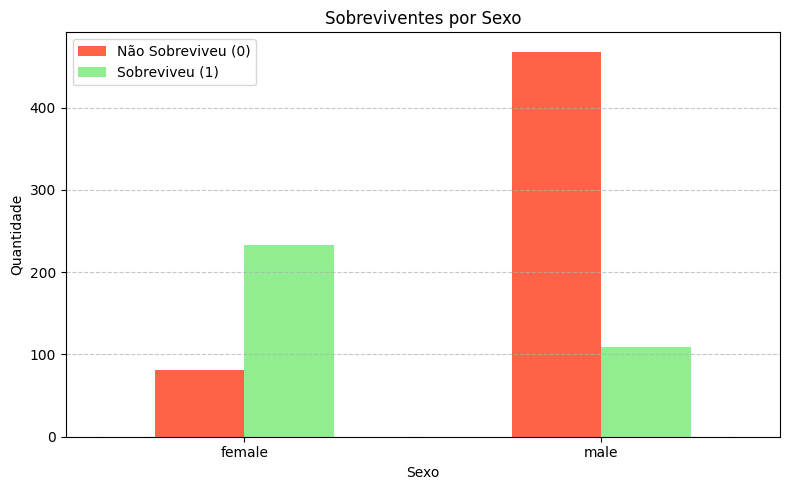

In [16]:
table = data_train_analytics.groupby(['Sex', 'Survived']).size().unstack()

table.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])

plt.title('Sobreviventes por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### When we look at embarkation by port, we notice that Port C, despite having the lowest number of passengers, shows the highest number of survivors compared to non-survivors at the same port. Meanwhile, Port S has the highest number of passengers but also the highest number of non-survivors.

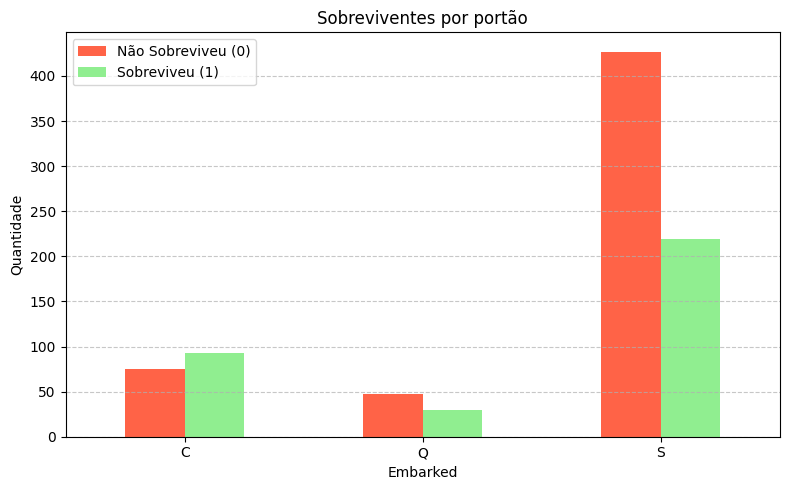

In [58]:
table = data_train_analytics.groupby(['Embarked', 'Survived']).size().unstack()

table.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])

plt.title('Sobreviventes por portão')
plt.xlabel('Embarked')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

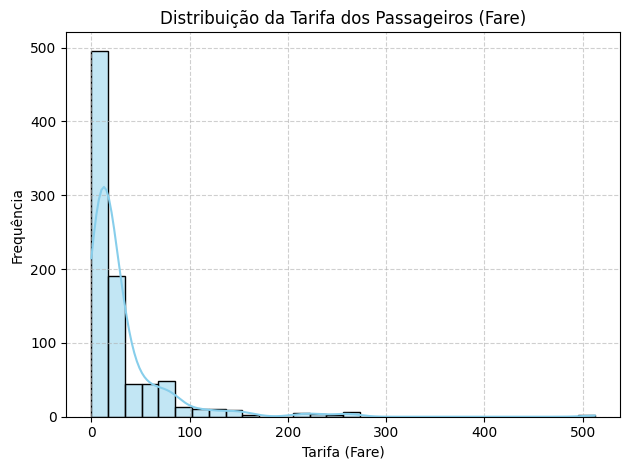

In [19]:
import seaborn as sns
sns.histplot(data_train_analytics['Fare'], kde=True, bins=30, color='skyblue')

plt.title('Distribuição da Tarifa dos Passageiros (Fare)')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### When we look at the ticket fares, we observe that those who paid more than 80 had a higher survival rate, while those who paid less were more likely not to survive. This may indicate that passengers who paid more had a better chance of survival. Similarly, females aged between 21 and 40 who paid higher fares also had a greater chance of surviving compared to others.

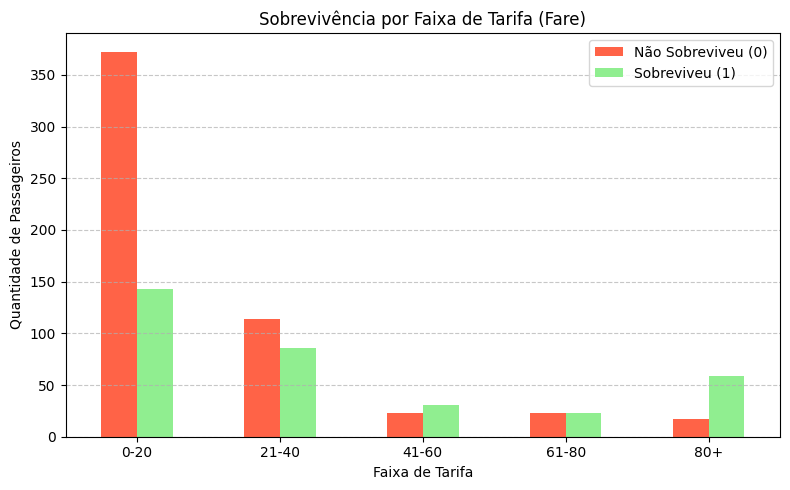

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

bins = [0, 20, 40, 60, 80, 1000]
labels = ['0-20', '21-40', '41-60', '61-80', '80+']

faixas_fare = pd.cut(data_train_analytics['Fare'], bins=bins, labels=labels, right=False)

tabela_fare = pd.crosstab(faixas_fare, data_train_analytics['Survived'])

tabela_fare.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])

plt.title('Sobrevivência por Faixa de Tarifa (Fare)')
plt.xlabel('Faixa de Tarifa')
plt.ylabel('Quantidade de Passageiros')
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


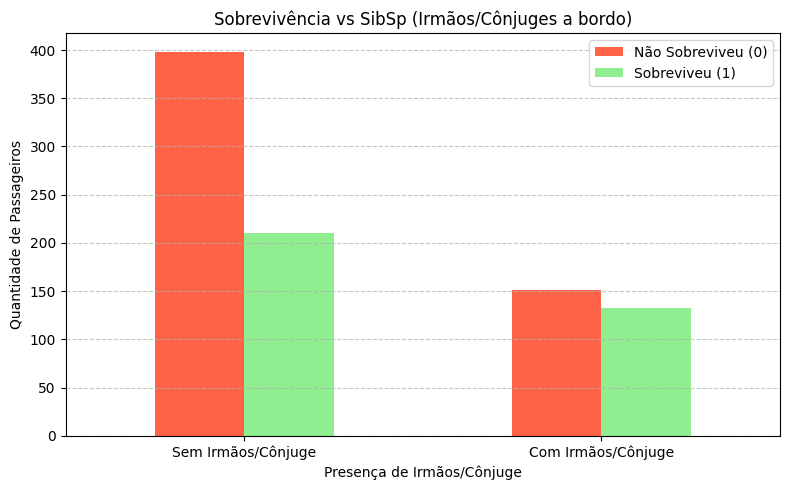

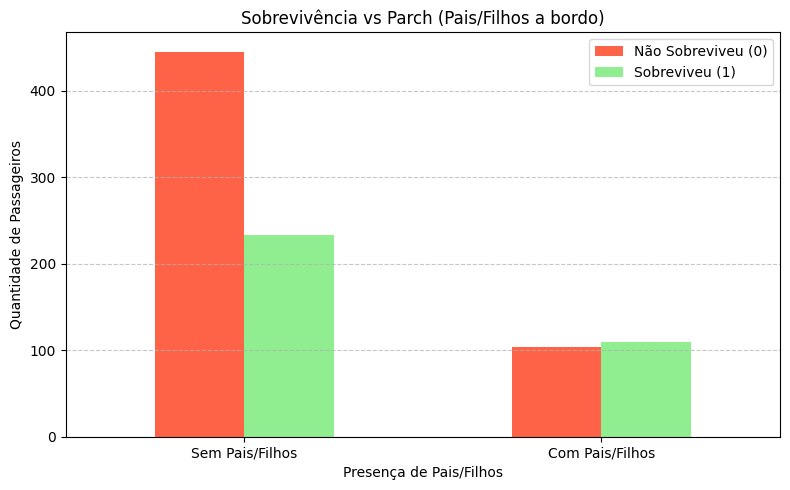

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data_train_analytics['Tem_SibSp'] = data_train_analytics['SibSp'] >= 1
data_train_analytics['Tem_Parch'] = data_train_analytics['Parch'] >= 1

tabela_sibsp = pd.crosstab(data_train_analytics['Tem_SibSp'], data_train_analytics['Survived'])
tabela_parch = pd.crosstab(data_train_analytics['Tem_Parch'], data_train_analytics['Survived'])

# Rename the indices to make the charts easier to read
tabela_sibsp.index = ['Sem Irmãos/Cônjuge', 'Com Irmãos/Cônjuge']
tabela_parch.index = ['Sem Pais/Filhos', 'Com Pais/Filhos']

# --- SibSp ---
tabela_sibsp.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])
plt.title('Sobrevivência vs SibSp (Irmãos/Cônjuges a bordo)')
plt.xlabel('Presença de Irmãos/Cônjuge')
plt.ylabel('Quantidade de Passageiros')
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Parch ---
tabela_parch.plot(kind='bar', figsize=(8, 5), color=['tomato', 'lightgreen'])
plt.title('Sobrevivência vs Parch (Pais/Filhos a bordo)')
plt.xlabel('Presença de Pais/Filhos')
plt.ylabel('Quantidade de Passageiros')
plt.legend(['Não Sobreviveu (0)', 'Sobreviveu (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


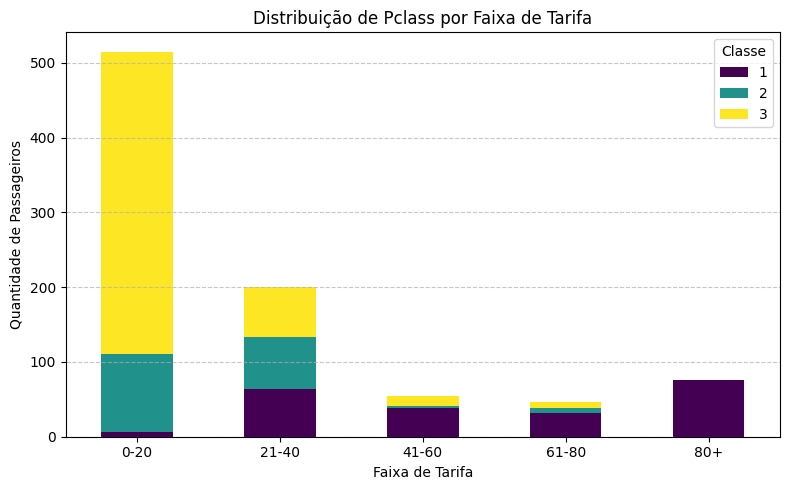

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

#  (bins)
bins = [0, 20, 40, 60, 80, 1000]
labels = ['0-20', '21-40', '41-60', '61-80', '80+']

ranges_fare = pd.cut(data_train_analytics['Fare'], bins=bins, labels=labels, right=False)

data_train_analytics['Faixa_Fare'] = ranges_fare

# Crosstab between Fare and Pclass
table_pclass_fare = pd.crosstab(data_train_analytics['Faixa_Fare'], data_train_analytics['Pclass'])

table_pclass_fare.plot(kind='bar', stacked=True, figsize=(8,5), colormap='viridis')

plt.title('Distribuição de Pclass por Faixa de Tarifa')
plt.xlabel('Faixa de Tarifa')
plt.ylabel('Quantidade de Passageiros')
plt.legend(title='Classe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


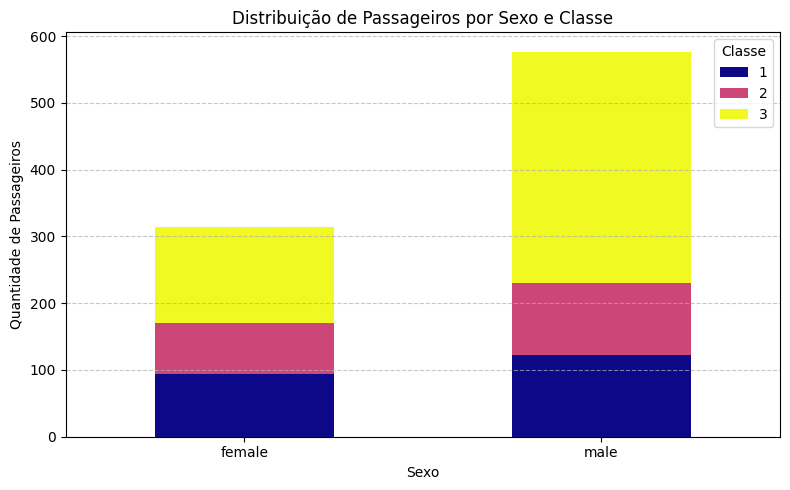

In [60]:
# Crosstab between Sex, Class and survived
table_sexo_classe = pd.crosstab(index=data_train_analytics['Sex'], 
                                 columns=data_train_analytics['Pclass'])

table_sexo_classe.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='plasma')

plt.title('Distribuição de Passageiros por Sexo e Classe')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de Passageiros')
plt.legend(title='Classe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

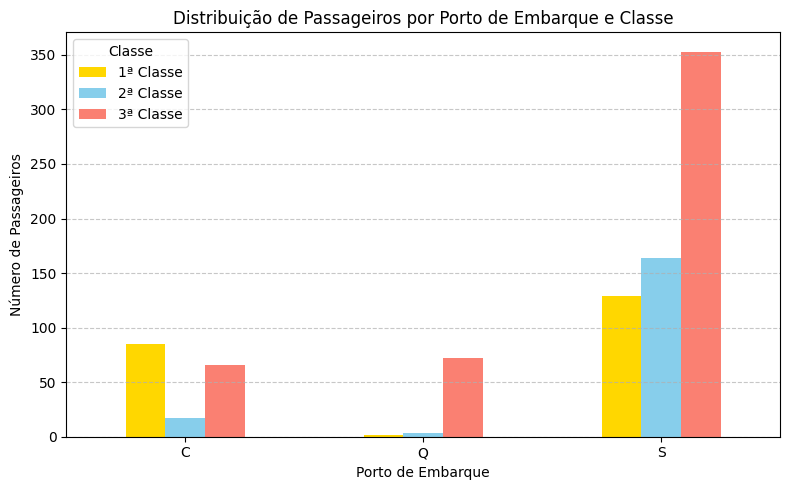

In [61]:
# Crosstab between Embarked and Survived
table_embarked_pclass = pd.crosstab(data_train_analytics['Embarked'], data_train_analytics['Pclass'])

table_embarked_pclass.columns = ['1ª Classe', '2ª Classe', '3ª Classe']

table_embarked_pclass.plot(kind='bar', figsize=(8, 5), color=['gold', 'skyblue', 'salmon'])

plt.title('Distribuição de Passageiros por Porto de Embarque e Classe')
plt.xlabel('Porto de Embarque')
plt.ylabel('Número de Passageiros')
plt.legend(loc='best', title='Classe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Let’s perform data preprocessing and save it for use in the models.
data_train_neural = pd.read_csv('train.csv')
data_test_neural = pd.read_csv('test.csv')

In [41]:
data_train_neural.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
data_train_neural['Age'].fillna(data_train_neural['Age'].median(), inplace=True)
data_train_neural['Fare'].fillna(data_train_neural['Fare'].median(), inplace=True)
data_train_neural['Embarked'].fillna(data_train_neural['Embarked'].mode()[0], inplace=True)

# # Remove all column which we not use
# data_train_neural = data_train_neural.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch', 'Embarked'])
data_train_neural = data_train_neural.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

/var/folders/94/5k1_ghp56xx72w4v2ly5kr1w0000gp/T/ipykernel_63330/1505630254.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train_neural['Age'].fillna(data_train_neural['Age'].median(), inplace=True)
/var/folders/94/5k1_ghp56xx72w4v2ly5kr1w0000gp/T/ipykernel_63330/1505630254.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on 

In [43]:
data_train_neural.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [44]:
# one hot encodedind no sexo e enbarked
df_encoded = pd.get_dummies(data_train_neural, columns=['Sex', 'Embarked'], drop_first=True)

# Converte todos os booleanos para inteiros (0 e 1)
df_encoded = df_encoded.astype(int)

In [45]:
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0
2,1,3,26,0,0,7,0,0,1
3,1,1,35,1,0,53,0,0,1
4,0,3,35,0,0,8,1,0,1


In [ ]:
data_test_neural['Age'].fillna(data_train_neural['Age'].median(), inplace=True)
data_test_neural['Fare'].fillna(data_train_neural['Fare'].median(), inplace=True)
data_test_neural['Embarked'].fillna(data_train_neural['Embarked'].mode()[0], inplace=True)

# # Remove all column which we not use
# data_test_neural = data_test_neural.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch', 'Embarked'])
data_test_neural = data_test_neural.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

In [48]:
# one hot encodedind no sexo e enbarked
df_encoded_test = pd.get_dummies(data_test_neural, columns=['Sex', 'Embarked'], drop_first=True)

# Convert all from boolean to int (0 e 1)
df_encoded_test = df_encoded_test.astype(int)

In [49]:
df_encoded_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34,0,0,7,1,1,0
1,3,47,1,0,7,0,0,1
2,2,62,0,0,9,1,1,0
3,3,27,0,0,8,1,0,1
4,3,22,1,1,12,0,0,1


In [50]:
# save to csv
df_encoded_test.to_csv("titanic_tratado_test.csv", index=False)
df_encoded.to_csv("titanic_tratado.csv", index=False)
